# Семинар 2. Визуализации и агрегации

## 1. Загрузка

In [1]:
import pandas as pd
pd.set_option('display.expand_frame_repr', False)

In [2]:
# большие данные часто лежат помесячно
# «партиция февраль 2024»
url_2024_01 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_01.csv"
url_2024_02 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_02.csv"
url_2024_03 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_03.csv"
url_2024_04 = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/sessions_2_2024_04.csv"

df_2024_01 = pd.read_csv(url_2024_01)
df_2024_02 = pd.read_csv(url_2024_02)
df_2024_03 = pd.read_csv(url_2024_03)
df_2024_04 = pd.read_csv(url_2024_04)

In [3]:
# ожидаем что данные полные
# проверим по-простому
print(df_2024_04.sort_values(by='session_start_dttm'))

# это всё - характеристики сессии (по ключу user_id + session_start_dttm)

      user_id   session_start_dttm  desktop_flag  satisfaction_metric  session_duration_min  purchase_flag  purchase_amount_rub
0       29614  2024-04-01 01:16:58             0                  NaN                    16              1                  344
1       96030  2024-04-01 01:44:22             1                  NaN                     7              1                  338
2        5032  2024-04-01 01:48:39             1                  NaN                     6              1                  332
3        6584  2024-04-01 01:51:06             0                  NaN                     7              0                    0
4       28199  2024-04-01 02:14:28             0                  NaN                     6              0                    0
...       ...                  ...           ...                  ...                   ...            ...                  ...
4552    81481  2024-04-30 23:24:44             1                  NaN                     5             

In [4]:
# input('проверить assert на каждую таблицу что dates not out of range')

# таким образом можно писать себе todo-шки

In [5]:
# соединяем
df = pd.concat(
    [df_2024_01, df_2024_02, df_2024_03, df_2024_04],
    axis=0 # по строкам
)

# Q: почему axis=0 - это строки, а axis=1 - столбцы?

# Q: если применить concat к таблицам с разным количеством столбцов, что получится в итоге?

A: _подсказка внутри_
<!--
<img src="https://i0.wp.com/indianaiproduction.com/wp-content/uploads/2019/06/NumPy-array.png?resize=640%2C307&ssl=1" width="700"> -->


In [6]:
# для визуализаций понадобятся характеристики юзера. Для них заглянем в таблицу users.csv
# такие таблицы называются справочниками - в них есть информация только о конкретном измерении

# если данные динамические (возраст, регион), то часто хранят снапшоты таблиц за прошлые даты

url_users = "https://github.com/polozkovdmitry/ada_hse_econ/raw/refs/heads/main/2026_spring/sem_2_vis/users_2_2024_04.csv"

df_users = pd.read_csv(url_users)
print(df_users)

      user_id      registered_dttm  male_flag  moscow_flag  age
0       75037  2023-05-30 01:48:26          0            0   27
1       86321  2023-05-30 03:15:26          1            0   30
2       45165  2023-05-30 03:30:09          1            0   26
3       73252  2023-05-30 04:58:02          1            1   31
4       29305  2023-05-30 09:26:57          1            0   31
...       ...                  ...        ...          ...  ...
4786    21718  2024-04-30 07:20:43          1            1   42
4787    14074  2024-04-30 07:57:15          0            0   28
4788    91351  2024-04-30 08:47:48          1            0   21
4789    34927  2024-04-30 14:27:11          1            1   32
4790    38246  2024-04-30 16:52:55          0            1   34

[4791 rows x 5 columns]


In [7]:
df = df.merge(
    df_users,
    left_on='user_id',
    right_on='user_id',
    how='left'
)
print(df)
# получился data mart - витрина
# (агрегирована с таблицами-справочниками)

       user_id   session_start_dttm  desktop_flag  satisfaction_metric  session_duration_min  purchase_flag  purchase_amount_rub      registered_dttm  male_flag  moscow_flag  age
0        95739  2024-01-01 00:19:48             0            -0.581311                     4              1                  199  2023-12-22 20:39:12          0            0   32
1        49362  2024-01-01 00:32:59             0             2.648112                    10              1                  173  2023-07-10 17:31:54          1            0   29
2        16377  2024-01-01 00:40:00             0             0.044688                     7              0                    0  2023-12-30 11:58:45          0            1   25
3        64361  2024-01-01 00:55:24             1             4.141648                     4              0                    0  2023-12-27 08:49:15          1            0   18
4        65977  2024-01-01 01:01:21             1             1.159844                     3             

In [8]:
df["registered_dttm"] = pd.to_datetime(df["registered_dttm"])
df["session_start_dttm"] = pd.to_datetime(df["session_start_dttm"])

df['user_id'] = df['user_id'].astype(str)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15672 entries, 0 to 15671
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               15672 non-null  object        
 1   session_start_dttm    15672 non-null  datetime64[ns]
 2   desktop_flag          15672 non-null  int64         
 3   satisfaction_metric   11115 non-null  float64       
 4   session_duration_min  15672 non-null  int64         
 5   purchase_flag         15672 non-null  int64         
 6   purchase_amount_rub   15672 non-null  int64         
 7   registered_dttm       15672 non-null  datetime64[ns]
 8   male_flag             15672 non-null  int64         
 9   moscow_flag           15672 non-null  int64         
 10  age                   15672 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(7), object(1)
memory usage: 1.3+ MB


## 2. Визуализации

In [9]:
# будем делать дневные

df["dt"] = df["session_start_dttm"].dt.date

### 2.1. Динамика

К вам поступил вопрос

> Сколько новых пользователей в день приходит? Интересна динамика за последний квартал

Ваши действия?

<img src="https://miro.medium.com/1*kwN_Y8GNf2ZB6sNQxngVyw@2x.jpeg" width="400">





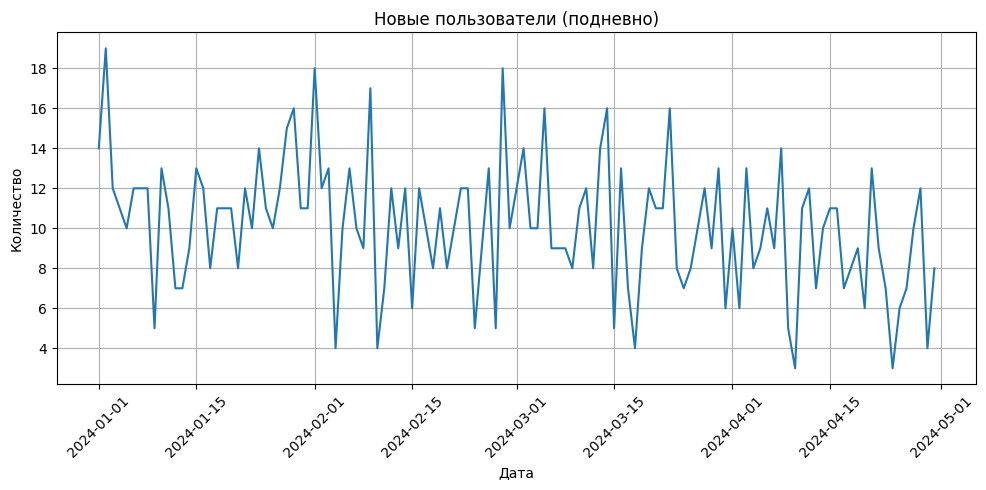

In [10]:
# оставляем только строки, где время первой сессии совпадает с временем регистрации
df_new_users = df[df["session_start_dttm"] == df["registered_dttm"]].copy()

# агрегируем по количеству пользователей в день
new_users_by_day = df_new_users.groupby("dt")['user_id'].count()
# Q: в чём разница с size()? а с nunique()?
# A: ответ ниже *

# график
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(new_users_by_day.index, new_users_by_day.values)
plt.title("Новые пользователи (подневно)")
plt.xlabel("Дата")
plt.ylabel("Количество")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# A
# * count считает только non null значения столбца (у нас все заполнены, разницы нет)
# nunique считает только уникальные (у нас по построению user_id регистрируется только один раз, разницы нет)

чтобы рассмотреть получше используем plotly

промпт для LLM:

```
добавь график в plotly

*вставьте код*
 ```

In [11]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=new_users_by_day.index,
    y=new_users_by_day.values,
    mode='lines',
    name='Новые пользователи (подневно)'
))

fig.update_layout(
    title="Новые пользователи (подневно)",
    xaxis_title="Дата",
    yaxis_title="Количество",
    template="plotly_white"
)

fig.show()

# Q: какие есть проблемы у графика, как его улучшить?

### 2.2. Статика по категориям


К вам поступил вопрос

> Для каждой сессии мы научились считать метрику удовлетворённости. Есть ли разница в разрезе типа устройства?

Ваши действия?

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQeel5O0jnCCY9hTrPzZkocOyvAhUlWN4O2rg&s" width="250">





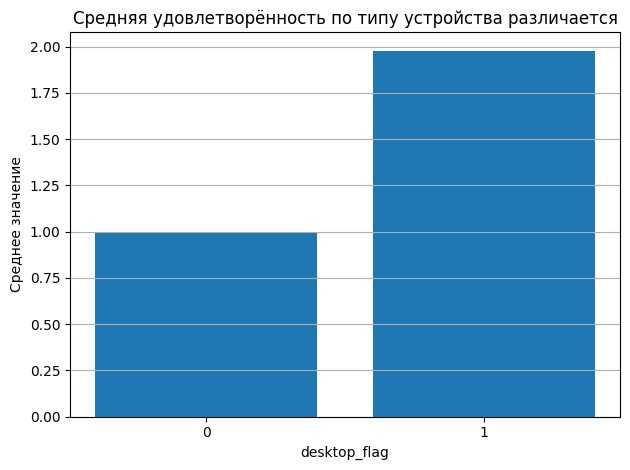

In [12]:
# генерировали в прошлом семинаре - зависит от desktop_flag

# агрегируем по нему
satisfaction_metric_by_desktop_flag = df.groupby("desktop_flag")['satisfaction_metric'].mean()

plt.bar(satisfaction_metric_by_desktop_flag.index, satisfaction_metric_by_desktop_flag.values)

plt.title("Средняя удовлетворённость по типу устройства различается")
plt.xlabel("desktop_flag")
plt.ylabel("Среднее значение")
plt.grid(axis='y')

plt.xticks([0, 1], ['0', '1'])
plt.tight_layout()
plt.show()

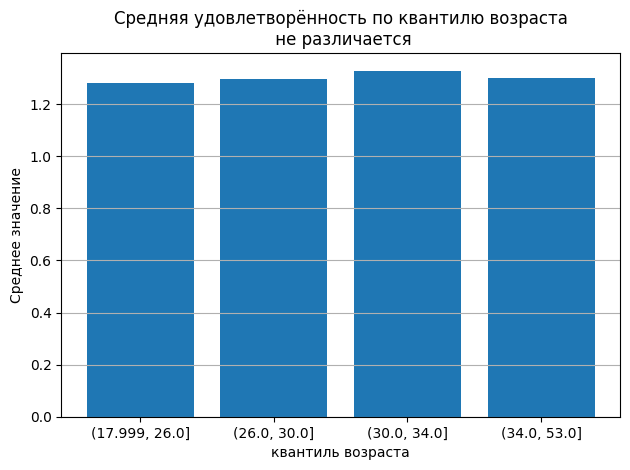

In [13]:
# если сагрегировать по-другому, то ничего полезного не увидим

# попробуем по возрасту
df['age_bucket'] = pd.qcut(df['age'], q=4).astype(str)


satisfaction_metric_by_age_bucket = df.groupby("age_bucket")['satisfaction_metric'].mean()

plt.bar(satisfaction_metric_by_age_bucket.index, satisfaction_metric_by_age_bucket.values)

plt.title("Средняя удовлетворённость по квантилю возраста\n не различается")
plt.xlabel("квантиль возраста")
plt.ylabel("Среднее значение")
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Q: может ли как-то возраст всё-таки помочь?

A: да, если совместить его с группировкой по значимому признаку

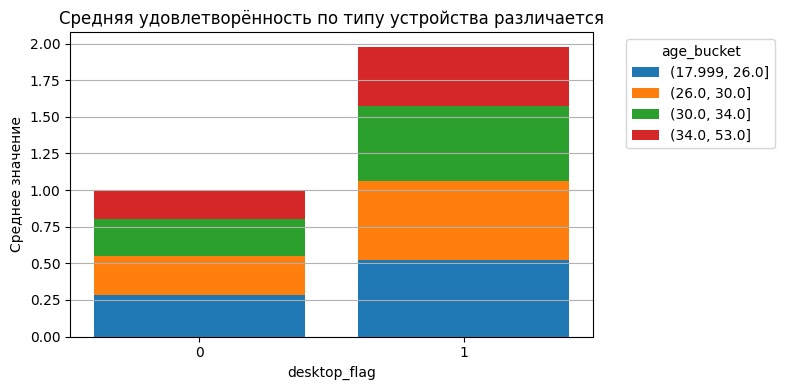

In [15]:
import numpy as np

# 1. Общая средняя удовлетворённость по desktop_flag
mean_sat = df.groupby("desktop_flag")["satisfaction_metric"].mean()

# 2. Доли age_bucket внутри каждого desktop_flag
age_shares = (
    df.groupby(["desktop_flag", "age_bucket"])
      .size()
      .unstack(fill_value=0)
)

age_shares = age_shares.div(age_shares.sum(axis=1), axis=0)

# 3. Превращаем доли в сегменты той же общей высоты, что и mean_sat
colored_parts = age_shares.mul(mean_sat, axis=0)

# 4. Рисуем обычные вертикальные бары, но из цветных сегментов
fig, ax = plt.subplots(figsize=(8, 4))

bottom = np.zeros(len(colored_parts))

for col in colored_parts.columns:
    ax.bar(
        colored_parts.index,
        colored_parts[col].values,
        bottom=bottom,
        label=col
    )
    bottom += colored_parts[col].values

ax.set_title("Средняя удовлетворённость по типу устройства различается")
ax.set_xlabel("desktop_flag")
ax.set_ylabel("Среднее значение")
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])
ax.grid(axis='y')
ax.legend(title="age_bucket", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Q: Как сделать график более читаемым?

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEDNaO_szfcX3i-YsbGwBES6TK84dwYcHrMg&s" width="500">

A: обратимся к LLM:

```
[current code]

this looks bad and unintuitive. i want a barplot with just the mean levels, and to the left and right of each one the pie charts of the age buckets

```

claude 4.6 sonnet выдал следующее

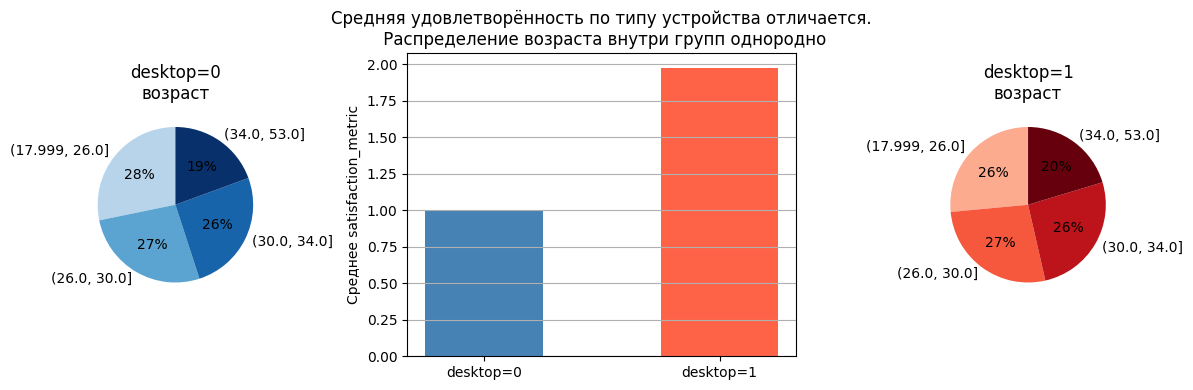

In [16]:
import matplotlib.gridspec as gridspec

groups = df.groupby("desktop_flag")

fig = plt.figure(figsize=(12, 4))
# 3 колонки: [пирог 0] [бар] [пирог 1]
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 2, 1])

ax_bar = fig.add_subplot(gs[1])
ax_pie0 = fig.add_subplot(gs[0])
ax_pie1 = fig.add_subplot(gs[2])

# --- Барплот: среднее satisfaction по desktop_flag ---
means = df.groupby("desktop_flag")['satisfaction_metric'].mean()
ax_bar.bar([0, 1], means.values, color=['steelblue', 'tomato'], width=0.5)
ax_bar.set_xticks([0, 1])
ax_bar.set_xticklabels(['desktop=0', 'desktop=1'])
ax_bar.set_ylabel("Среднее satisfaction_metric")
ax_bar.set_title("Средняя удовлетворённость по типу устройства отличается.\n Распределение возраста внутри групп однородно")
ax_bar.grid(axis='y')

# --- Пироги: распределение age_bucket внутри каждой группы ---
for ax_pie, flag, title, colors in [
    (ax_pie0, 0, "desktop=0\nвозраст", plt.cm.Blues),
    (ax_pie1, 1, "desktop=1\nвозраст", plt.cm.Reds),
]:
    age_dist = groups.get_group(flag)['age_bucket'].value_counts().sort_index()
    n = len(age_dist)
    ax_pie.pie(
        age_dist.values,
        labels=age_dist.index,
        autopct='%1.0f%%',
        colors=[colors(i / n + 0.3) for i in range(n)],
        startangle=90,
    )
    ax_pie.set_title(title)

plt.tight_layout()
plt.show()

# Q: какие ещё косметические улучшения приходят на ум?

### 2.3. Парные взаимосвязи

Q: как объяснить этот график семикласснику? (он уже знает что такое гистограмма)

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2024/02/image-535.png" width="700">

Q: а что если на диагонали пытаться делать scatterplot, как в остальных ячейках?

In [17]:
# в принципе, как искать зависимости? полезно сравнить признаки по парам

# выберем только то, что интересует
print(*df.columns, sep='\n')

user_id
session_start_dttm
desktop_flag
satisfaction_metric
session_duration_min
purchase_flag
purchase_amount_rub
registered_dttm
male_flag
moscow_flag
age
dt
age_bucket


In [18]:
cols_for_pairplot = [
    'desktop_flag',
    'satisfaction_metric',
    'session_duration_min',
    'purchase_flag',
    'purchase_amount_rub',
    'male_flag',
    'moscow_flag',
    'age',
    'dt'
]

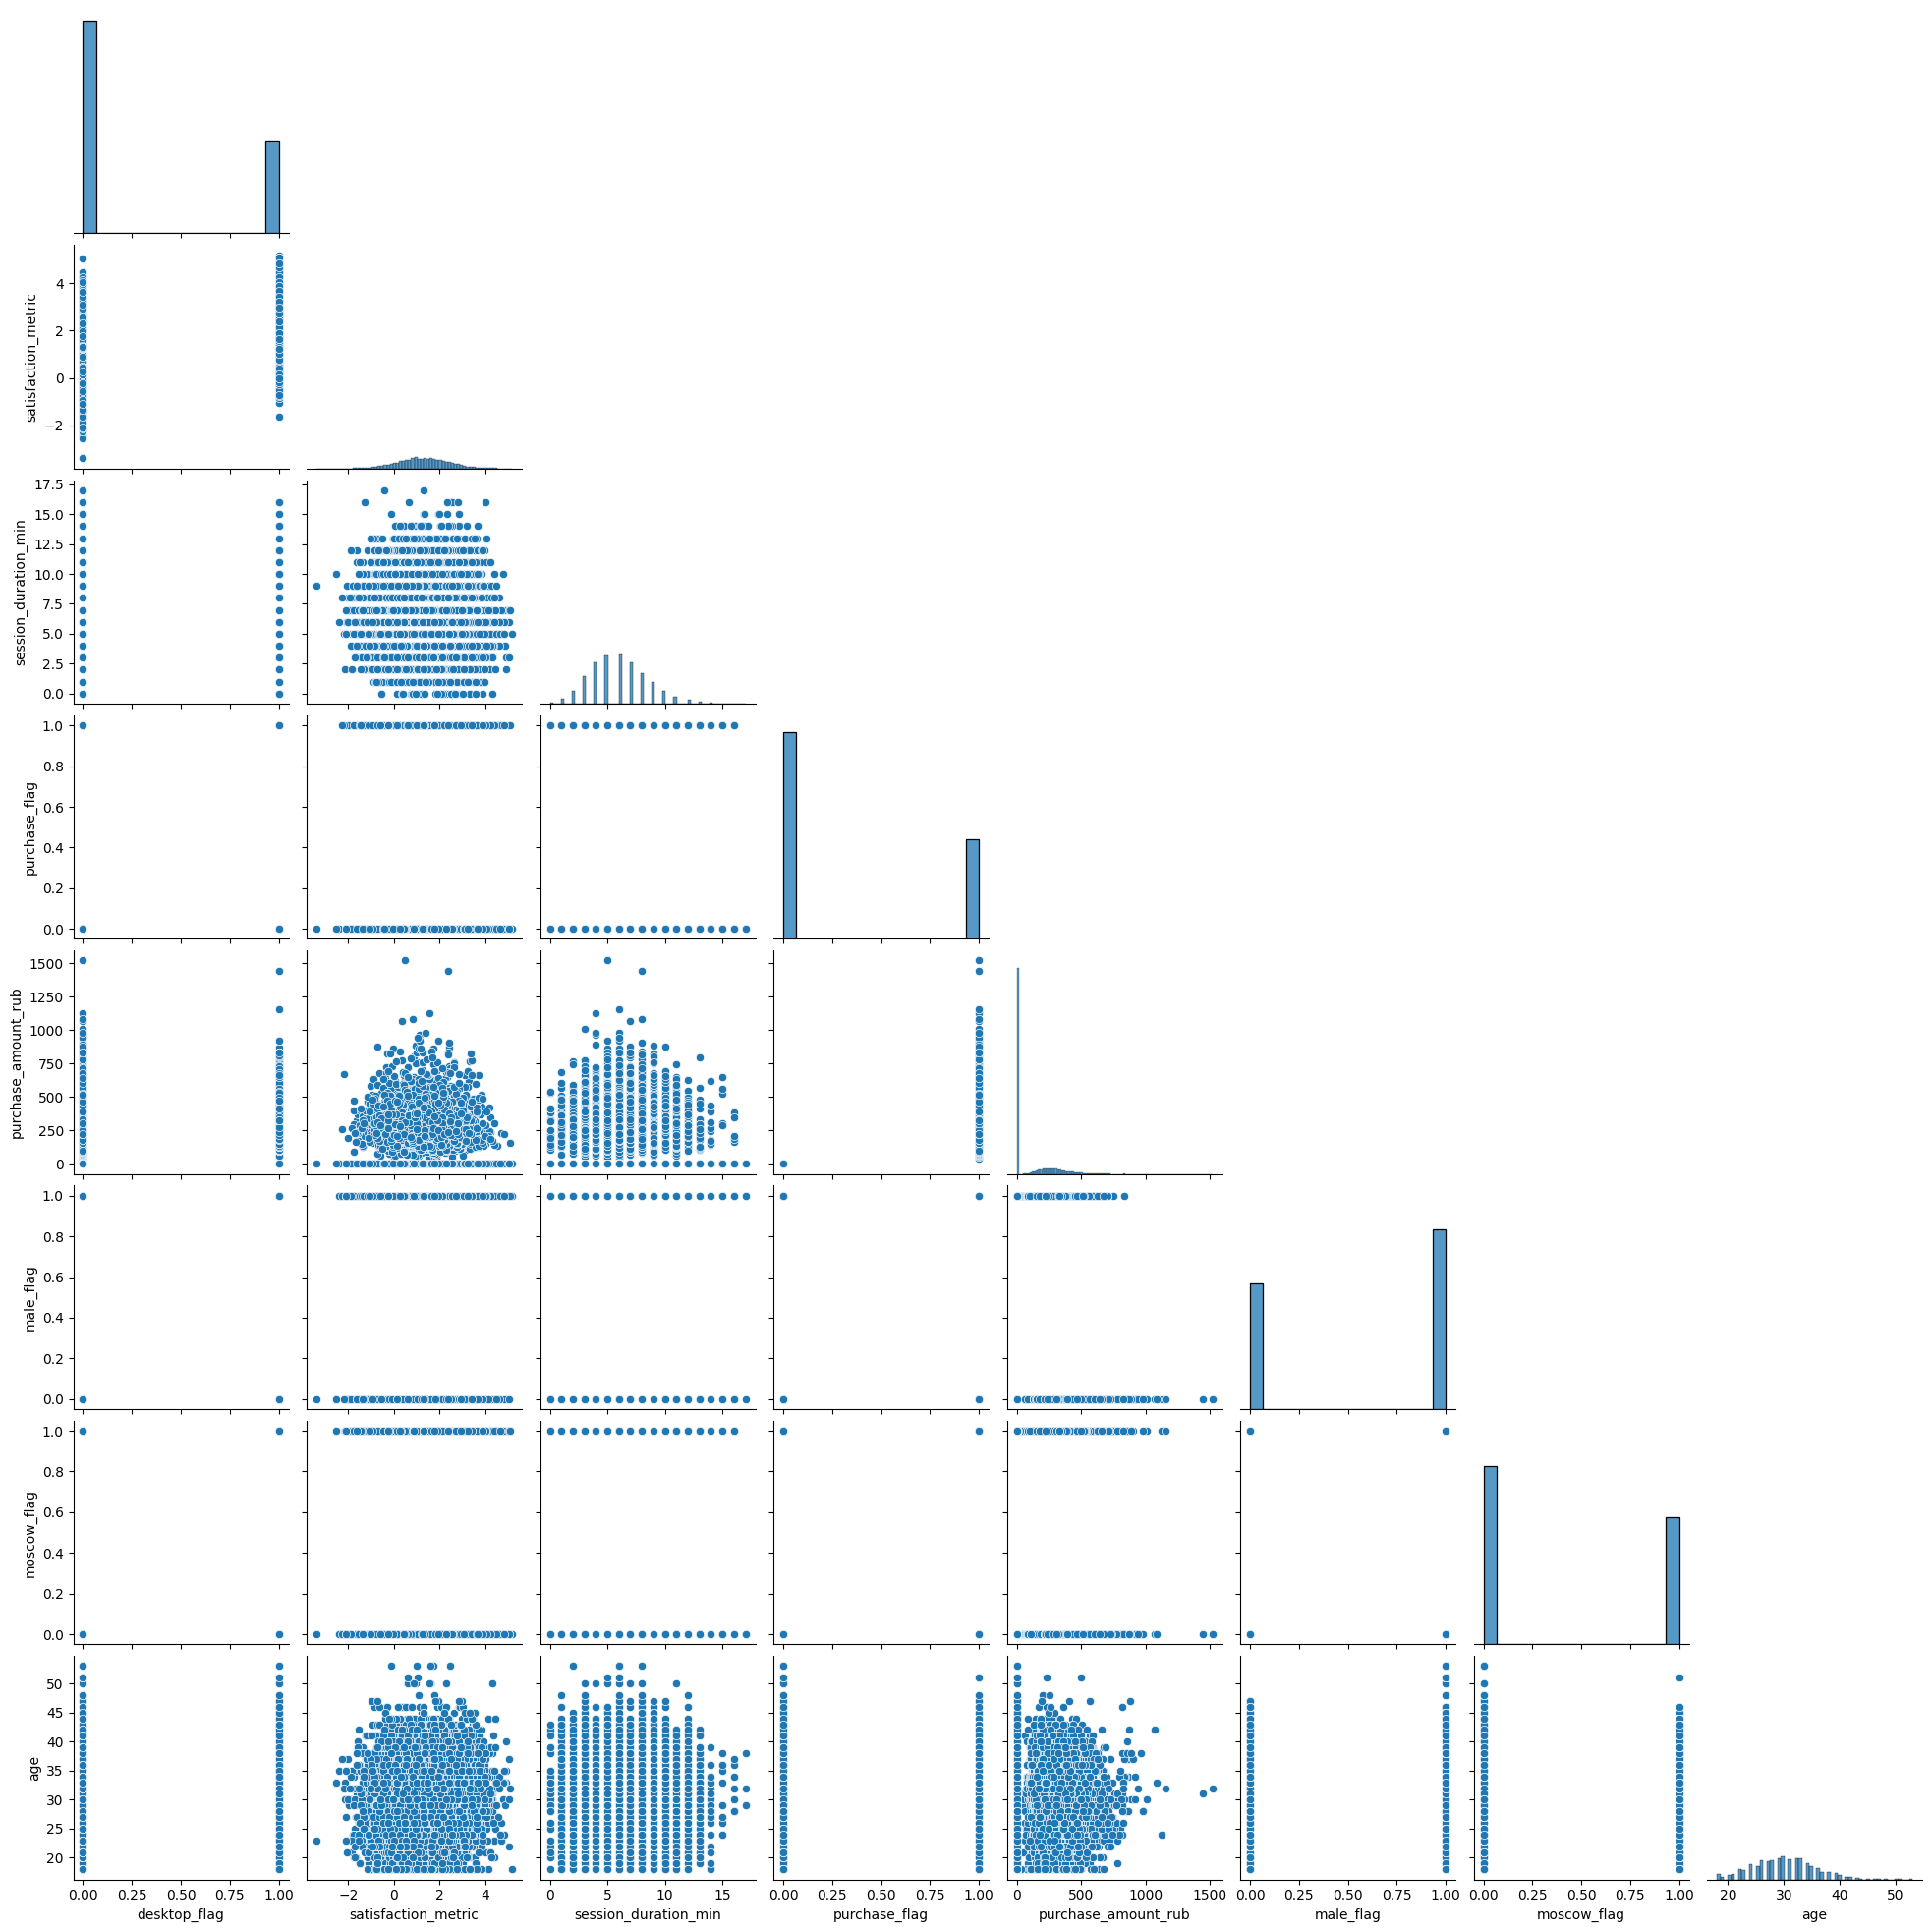

In [19]:
import seaborn as sns

sns.pairplot(
    df[cols_for_pairplot],
    corner=True
)
plt.show()

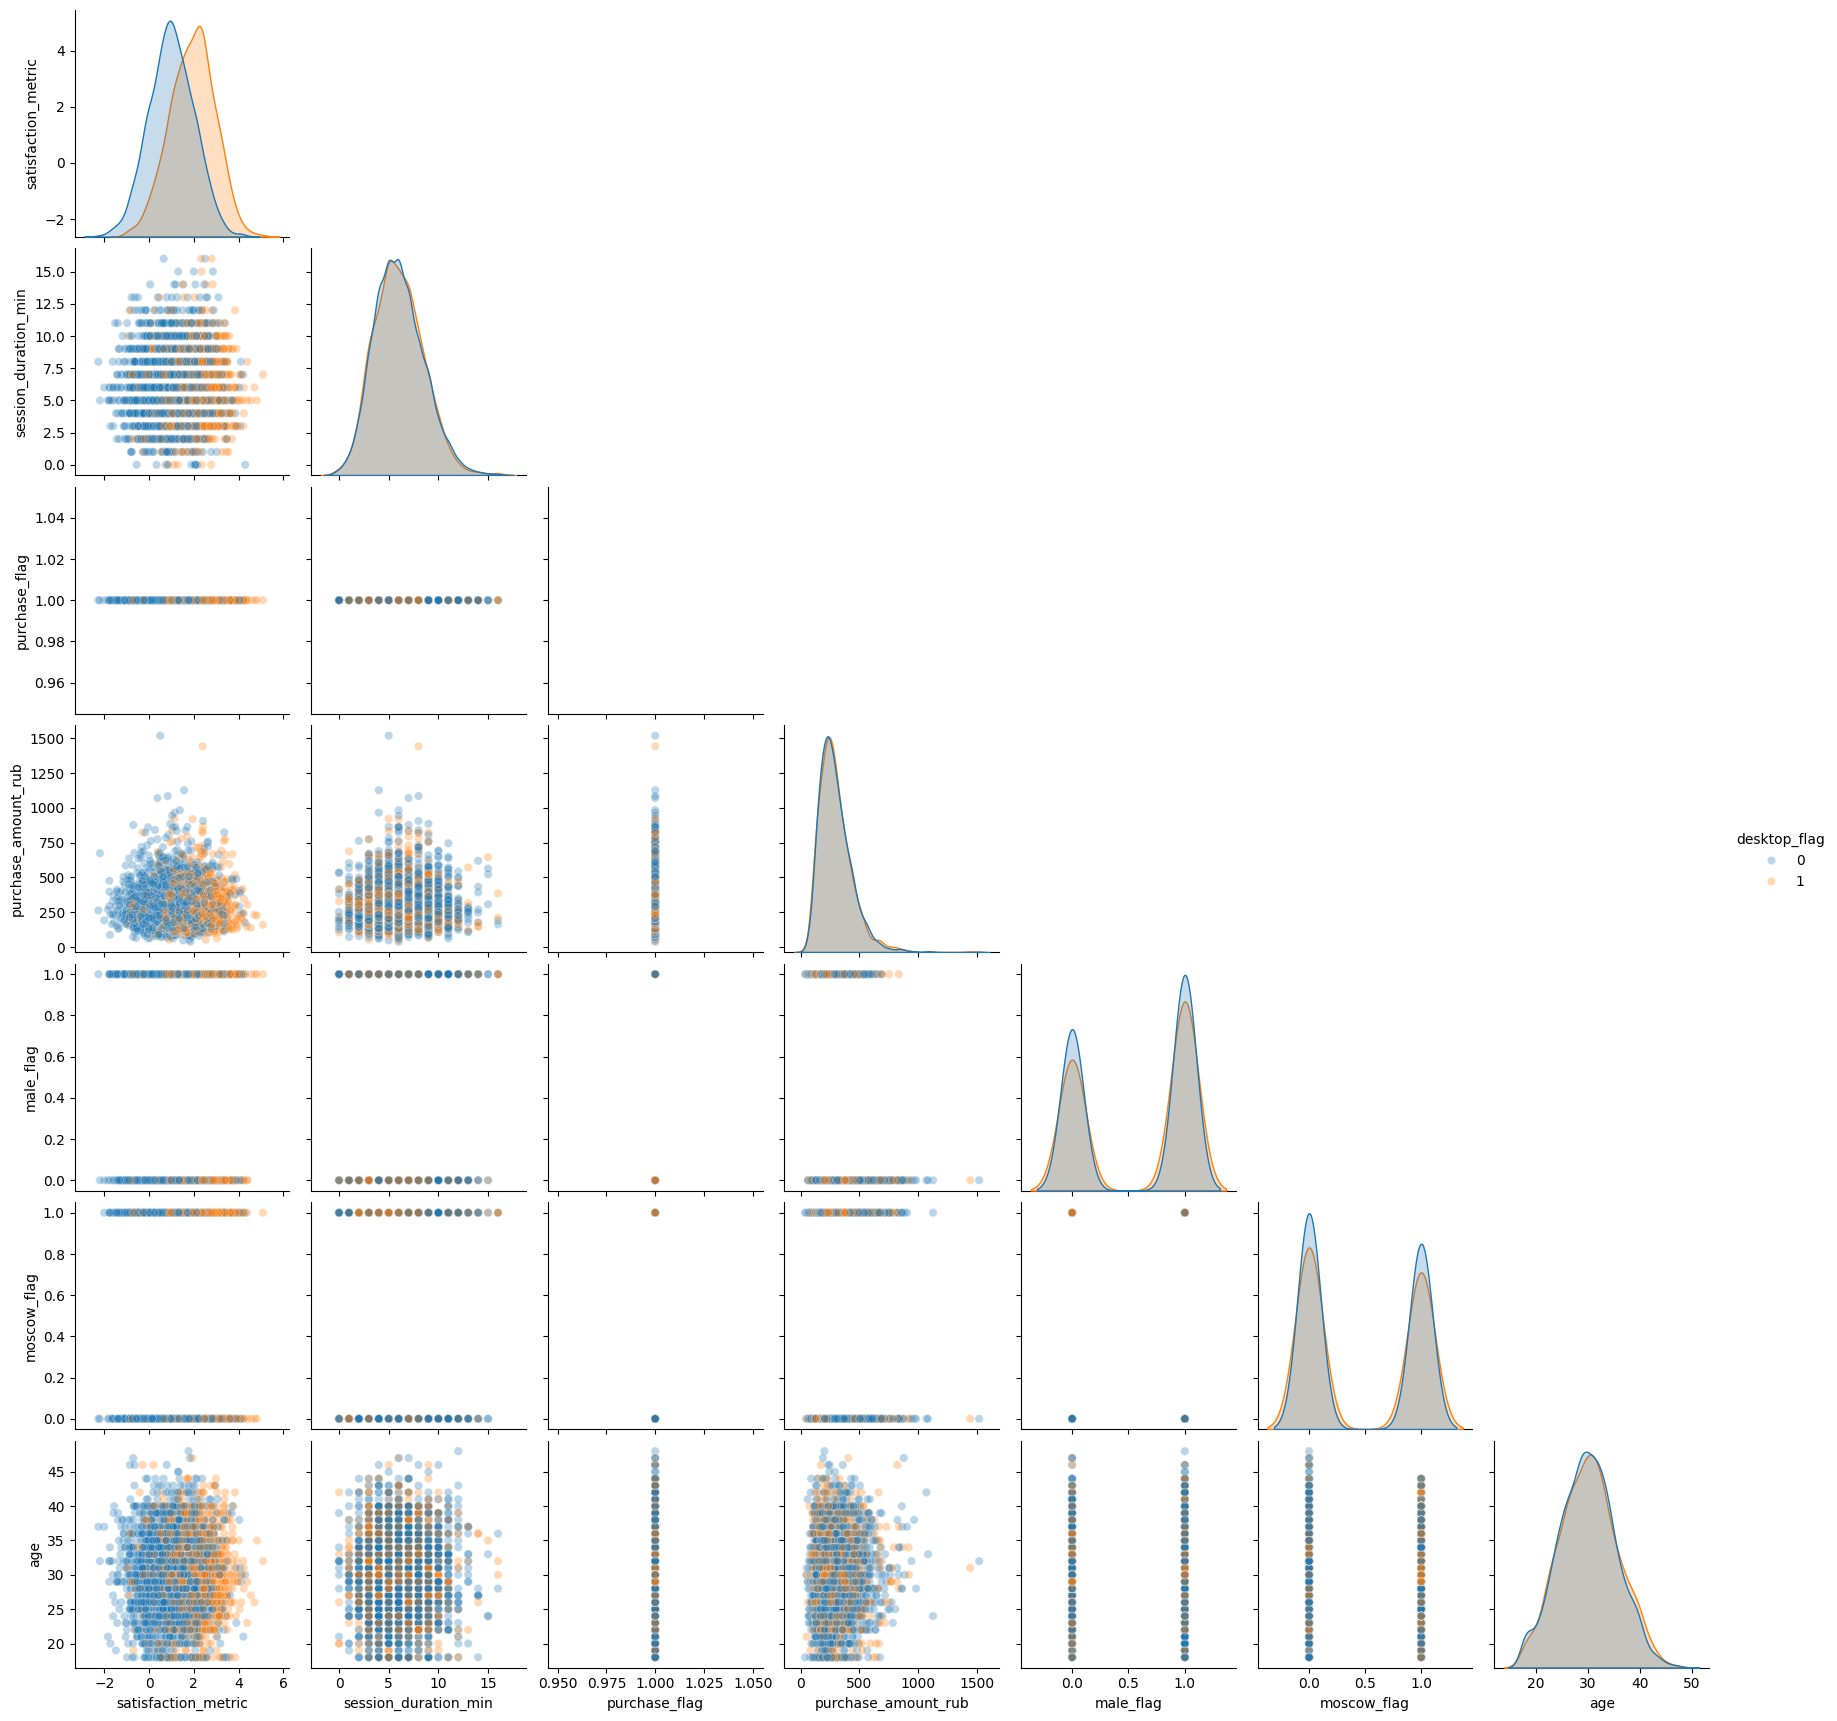

In [20]:
# лучше для интерпретации:
# - выбрать срез данных (только Q1 2024)
# - выбрать только платящих / не платящих
# - покрасить в цвет (из продуктовой логики)
# - если всё ещё много точек, снизить alpha или сменить scatter на 2D гистограмму

df_sample = df[df['session_start_dttm'].between(pd.Timestamp(2024, 1, 1), pd.Timestamp(2024, 4, 1))]
# на подумать: почему df['dt'].between... сломается?

df_sample = df_sample[df_sample['purchase_flag'] == 1]

g = sns.pairplot(
    df_sample[cols_for_pairplot],
    hue='desktop_flag',
    diag_kind="kde",
    diag_kws={"common_norm": False},
    plot_kws={'alpha': 0.3}
)

import numpy as np
for i, j in zip(*np.triu_indices_from(g.axes, 1)):
    g.axes[i, j].set_visible(False)

plt.show()

Q: когда полезна диаграмма ниже?

<img src="https://i.sstatic.net/W5KL1.png" width="700">

A: когда есть показатель «важности» наблюдения

Q: petal_width влияет на радиус или площадь точки?

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRgv5PskaP6expiqdoE7maiCUWqc399A8jdvA&s" width="400">

A: судя по легенде, на радиус. Когда хочется обратить внимание на самые жирные точки, можно попробовать делать через площадь (это cherry picking)


## 3. RFM

Вам поступил вопрос:

> Как поделить пользователей на категории активности + платежеспособности?

Какие критерии предложите и как разделите по категориям?

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS57SFx_iAQe-dfrPE0u6lCdwwM0XsaJ-rnSw&s" width="400">

Логика RFM:

1. Делим пользователей по совокупности признаков
- сколько дней прошло с последней сессии → R
- количество действий → F
- сумма покупок → M
2. В зависимости от квантилей, присвоим скоры

In [21]:
# текущая дата
current_date = df['session_start_dttm'].max() + pd.Timedelta(days=1)
print(current_date)

2024-05-01 23:59:43


In [22]:
rfm = df.groupby('user_id').agg({
    'session_start_dttm': 'max',     # последняя активность
    'user_id': 'count',              # количество действий (сессий)
    'purchase_amount_rub': 'sum'     # сумма покупок
}).rename(columns={
    'session_start_dttm': 'last_session',
    'user_id': 'frequency',
    'purchase_amount_rub': 'monetary'
}).reset_index()

# Recency = сколько дней прошло с последней сессии
rfm['recency'] = (current_date - rfm['last_session']).dt.days

In [23]:
import plotly.express as px

fig_r = px.histogram(rfm, x='recency', nbins=20, title='Распределение показателя R<br>(сколько дней прошло с последней сессии)')
# <br> есть аналог \n для plotly
fig_r.show()

In [24]:
# на основании диаграммы, выберем логичные пороги
def r_score(x):
    if x <= 7:
        return 1
    elif x <= 60: # тут не надо прописывать x > 7, потому что к этому условию и так перейдут только x > 7
        return 2
    else:
        return 3


rfm['R'] = rfm['recency'].apply(r_score)

print(rfm['R'].value_counts())



R
2    1562
3    1071
1     702
Name: count, dtype: int64


In [25]:
fig_f = px.histogram(rfm, x='frequency', nbins=20, title='Распределение показателя F<br>(сколько сессий было за последние 4 месяца)')
fig_f.show()


In [26]:
def f_score(x):
    if x >= 8:
        return 1
    elif x >= 3:
        return 2
    else:
        return 3

rfm['F'] = rfm['frequency'].apply(f_score)

print(rfm['F'].value_counts())


F
2    1530
3    1154
1     651
Name: count, dtype: int64


In [27]:
# fig_m = px.histogram(rfm, x='monetary', nbins=20, title='Распределение показателя M<br>(сколько рублей потрачено за последние 4 месяца)')
# fig_m.show()

rfm_filtered = rfm[rfm['monetary'] <= 1000]
fig_m = px.histogram(rfm_filtered, x='monetary', nbins=20, title='Monetary')
fig_m.show()

In [28]:
def m_score(x):
    if x >= 1000:
        return 1
    elif x >= 100:
        return 2
    else:
        return 3

rfm['M'] = rfm['monetary'].apply(m_score)

print(rfm['M'].value_counts())

M
2    1861
3     995
1     479
Name: count, dtype: int64


In [29]:
rfm['RFM'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

def segment(row):
    if row['RFM'] == '111':
        return 'лучшие'
    elif row['RFM'] in ['112', '113', '122']:
        return 'лояльные'
    elif row['RFM'] in ['121', '211', '221']:
        return 'крупные'
    elif row['RFM'] in ['231', '311', '321', '331']:
        return 'крупные неактивные'
    elif row['R'] == 2:
        return 'неактивные'
    elif row['RFM'] in ['123', '131', '132', '133']:
        return 'новые'
    elif row['RFM'] in ['312', '313', '322', '323']:
        return 'почти потерянные'
    elif row['RFM'] in ['332', '333']:
        return 'ушедшие'
    else:
        return 'other'

rfm['segment'] = rfm.apply(segment, axis=1)

print(rfm['segment'].value_counts())

segment
неактивные            1296
ушедшие                559
почти потерянные       473
лояльные               316
крупные                307
новые                  212
лучшие                 132
крупные неактивные      40
Name: count, dtype: int64


## 4. Гипотезы с помощью визуализаций

К вам поступил вопрос:

> Привет! я продакт Дима, смотрю на дэш X и вижу резкий рост среднего чека в марте, на глаз примерно на 30 рублей. Я прав, нигде не ошибаюсь?

Как будем проверять?

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR75J2iJqyYDhIhHaxSn-0LmoLxNLzMGD4NGQ&s" width="600">



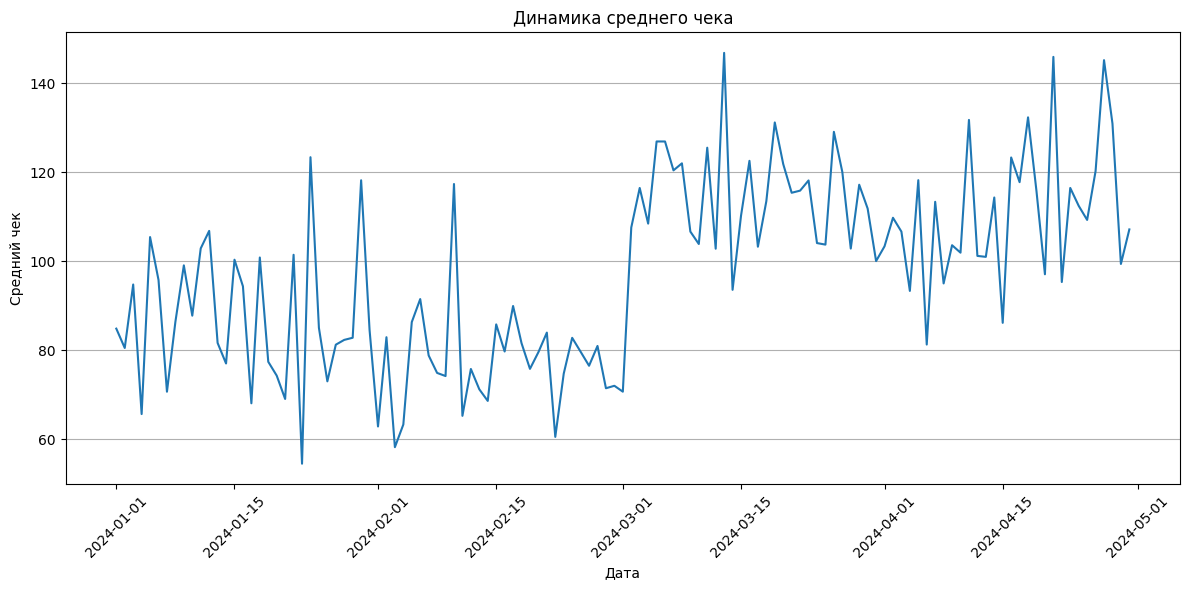

In [30]:
# средний чек по дням
daily_avg = df.groupby('dt')['purchase_amount_rub'].mean()
# график
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg.values)
plt.grid(axis='y')
plt.xlabel('Дата')
plt.ylabel('Средний чек')
plt.title('Динамика среднего чека')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

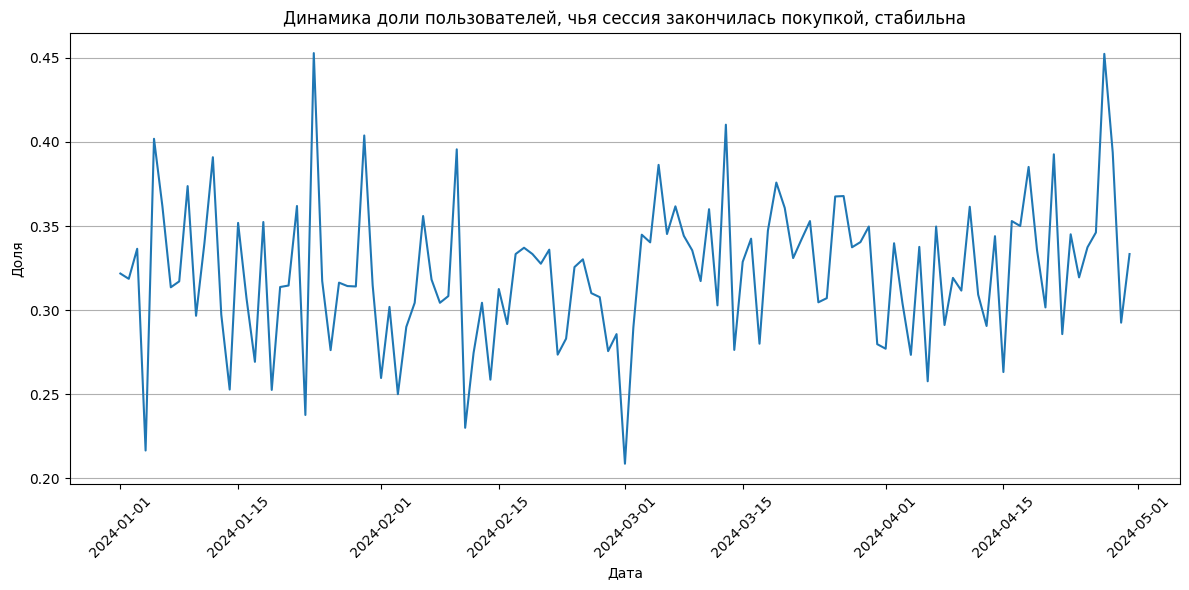

In [31]:
# мудрый аналитик всегда декомпозирует:
# purchase_amount может быть либо 0, либо >0, и кажется это разные ситуации

# изменилось ли что-то в динамике purchase_flag?

# доля купивших по дням
daily_avg = df.groupby('dt')['purchase_flag'].mean()
# график
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg.values)
plt.grid(axis='y')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.title('Динамика доли пользователей, чья сессия закончилась покупкой, стабильна')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

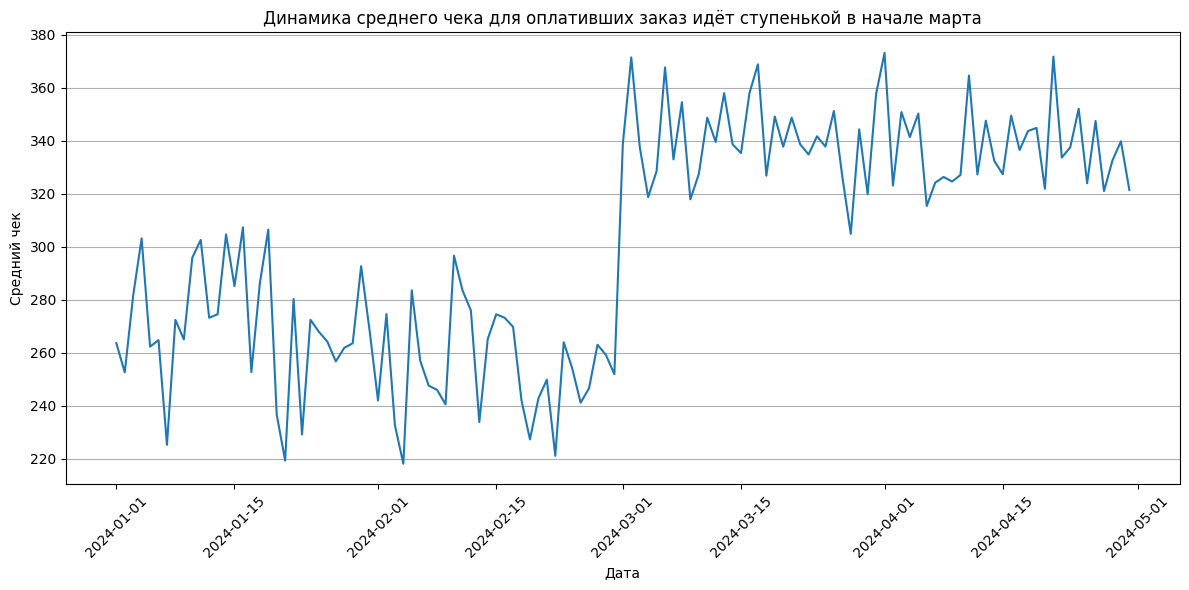

In [32]:
# кажется, что нет
# значит уберём эти данные из графика

df_plot = df[df['purchase_flag'] == 1].copy() # .copy() нужно т.к. без этого изменения в df_plot отразятся на df
daily_avg = df_plot.groupby('dt')['purchase_amount_rub'].mean()
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg.values)
plt.grid(axis='y')
plt.xlabel('Дата')
plt.ylabel('Средний чек')
plt.title('Динамика среднего чека для оплативших заказ идёт ступенькой в начале марта')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Q: как диагностировать причину?

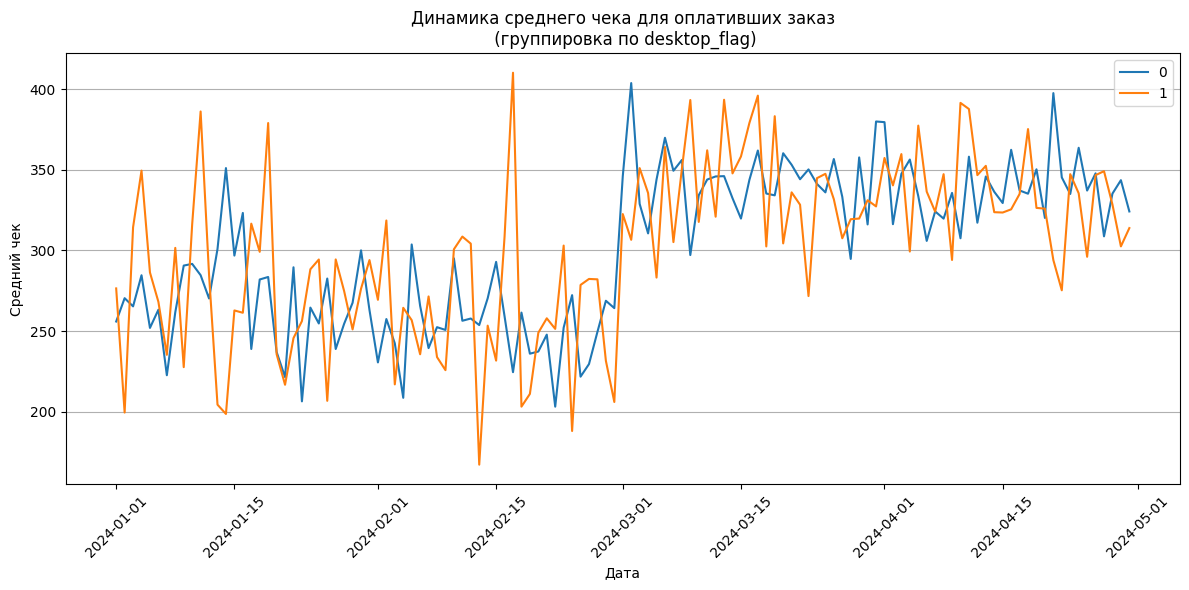

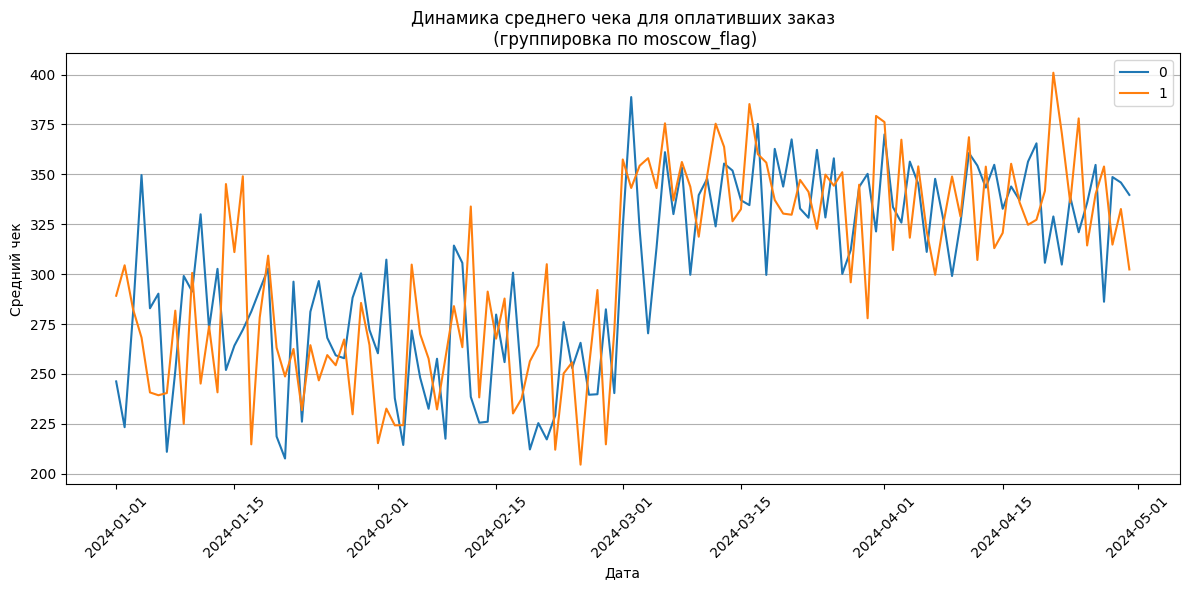

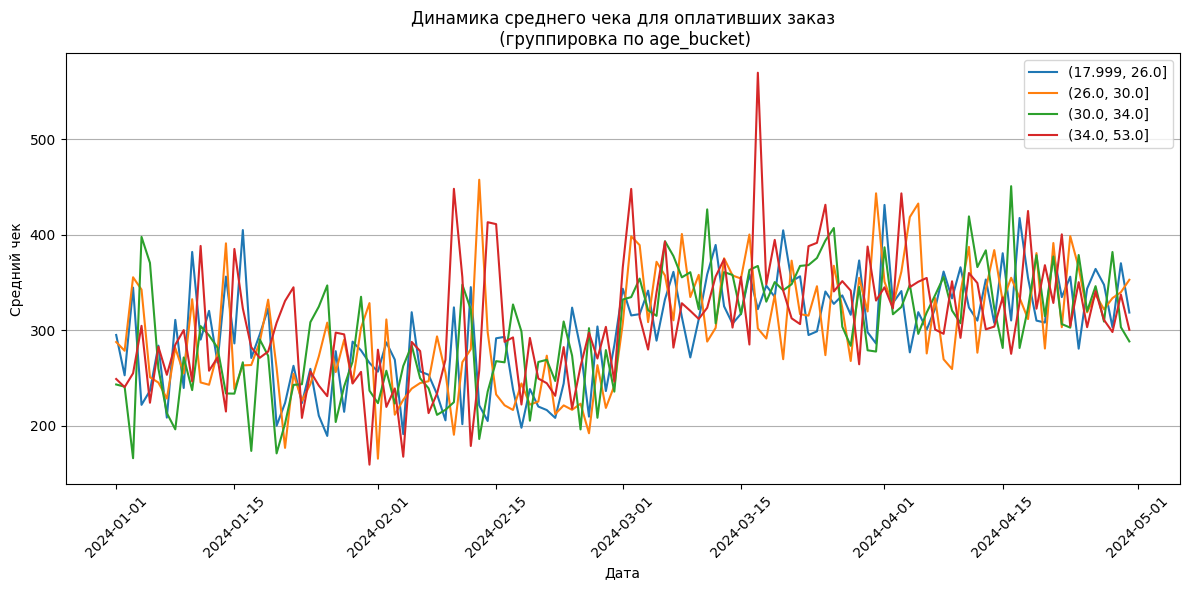

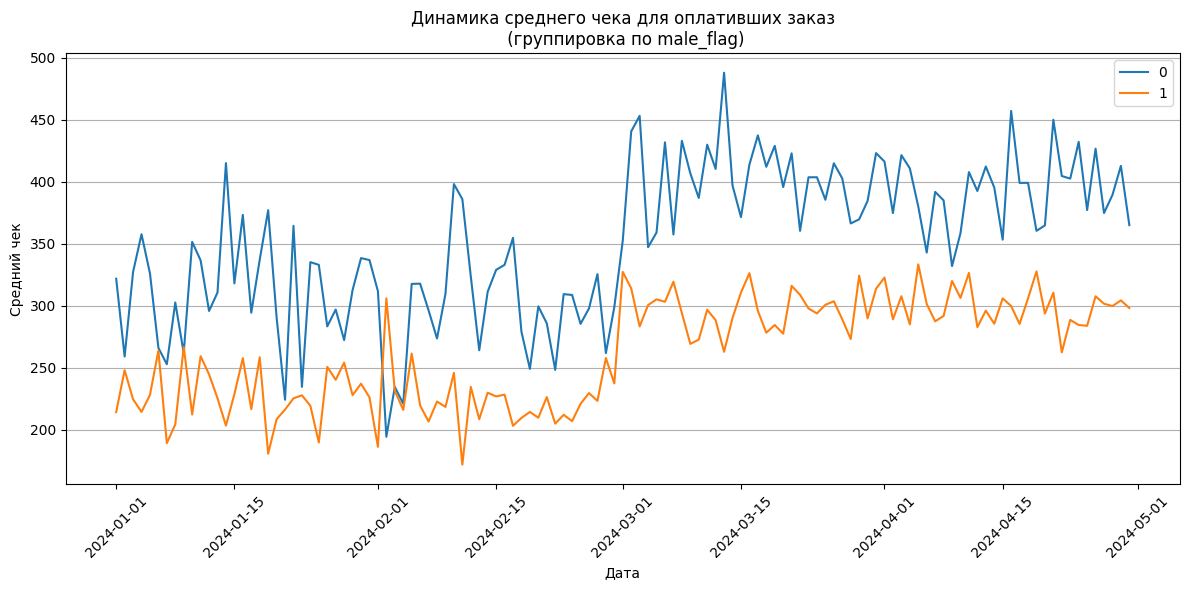

In [33]:
# A: пробовать рисовать в разных категориальных группировках

cols_possible_cause = [
    'desktop_flag',
    'moscow_flag',
    'age_bucket',
    'male_flag',
]

for col in cols_possible_cause:
    # группировка по дню и категории (один столбец с метрикой)
    # ключ dt + col
    daily_avg = df_plot.groupby(['dt', col])['purchase_amount_rub'].mean().reset_index()

    # сделать категорию из одного столбца в несколько (в каждом значения метрики)
    # ключ dt
    pivot_df = daily_avg.pivot(index='dt', columns=col, values='purchase_amount_rub')

    plt.figure(figsize=(12, 6))

    # нанесём на график все категории
    for column in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[column], label=str(column))

    plt.grid(axis='y')
    plt.xlabel('Дата')
    plt.ylabel('Средний чек')
    plt.title(f'Динамика среднего чека для оплативших заказ\n (группировка по {col})')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# на подумать: а как рисовать в группировках по непрерывным переменным, например satisfaction_metric?
# подсказка: см. переменную age_bucket

In [34]:
# вывод, с которым можно вернуться к продакту

# «первого марта средний чек среди тех, кто купил, вырос, причём у мужчин на X рублей, а у женщин на Y рублей. Что случилось в этот момент?»

# возможная реальная причина: после добавления в корзину появилась акция комплиментарных товаров - «с этим берут...»

df_plot_male = df_plot[df_plot['male_flag'] == 1]
df_plot_female = df_plot[df_plot['male_flag'] == 0]

X = (
    df_plot_male[df_plot_male['session_start_dttm'] >= pd.Timestamp(2024, 3, 1)]['purchase_amount_rub'].mean() \
    - df_plot_male[df_plot_male['session_start_dttm'] <= pd.Timestamp(2024, 3, 1)]['purchase_amount_rub'].mean()
)
print('X =', int(X))
Y = (
    df_plot_female[df_plot_female['session_start_dttm'] >= pd.Timestamp(2024, 3, 1)]['purchase_amount_rub'].mean() \
    - df_plot_female[df_plot_female['session_start_dttm'] <= pd.Timestamp(2024, 3, 1)]['purchase_amount_rub'].mean()
)
print('Y =', int(Y))

X = 70
Y = 90
